# Can AI Detect Fake News?

Every day, millions of news articles and social media posts are shared online. While many are written by reputable journalists, others contain misleading or completely false information. This raises an important question: Can AI help us identify fake news?

In this project, you will build a **Natural Language Processing (NLP)** model that reads news headlines and predicts whether the headline is real or fake. By converting text into numerical features, we can train machine learning models to recognize patterns in language that often appear in misleading headlines.

Along the way, you will explore how text data is processed, how words are represented as numbers, and how models learn from patterns in language.

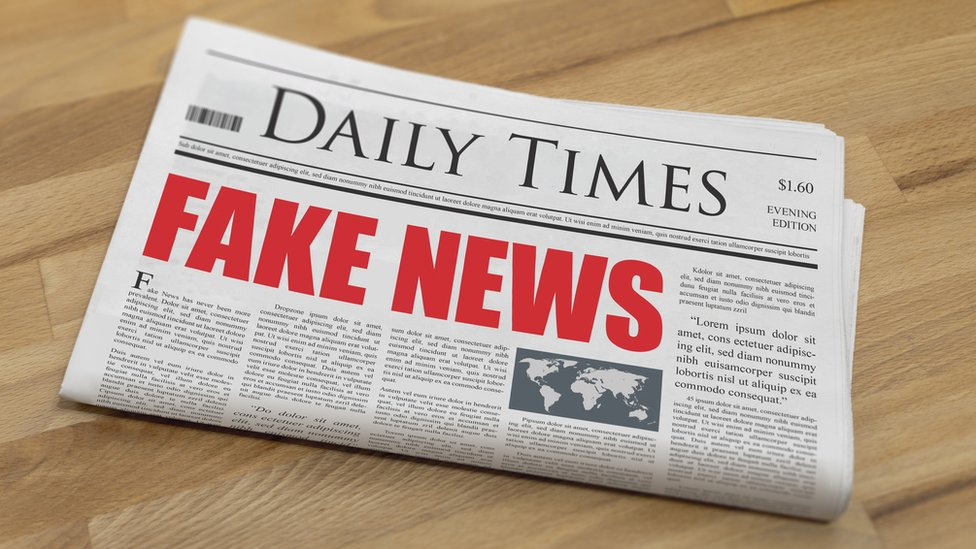

#### The Dataset - `news_dat`

**Description**
This dataset contains a collection of news articles labeled as either real news or fake news. The articles were gathered from a combination of news organizations and websites known for publishing misleading or fabricated stories.

The dataset includes tens of thousands of news articles covering a variety of political topics, primarily from the years 2016–2017, when concerns about misinformation and online news credibility were particularly prominent. Each article contains a headline, the full text of the article, the subject category, and the publication date.

For this project, we will combine the two files in the dataset (Fake.csv and True.csv) and convert them into a single dataset with a binary target variable:

**Fake**

0 = Real News

1 = Fake News

**Variables**
- `title`: Headline of news article
- `text`: Full text content of the article
- `subject`: Topic category of the artcile (e.g., politics, world news)
- `date`: Publication date of the article
- `Fake`: Target variable used for prediction(0 = Real News, 1 = Fake News)


**Data Source**

All the data for this project was gathered <a href="https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset">here on Kaggle</a>.

- Bisaillon, Clément. Fake and Real News Dataset. Kaggle, 2020.

#### Getting set up
First, let's download our packages and dataset

In [1]:
# Download the pandas and numpy libraries, which contain helpful Python commands
import pandas as pd
import numpy as np

# Download the seaborn library, which contains useful data visualization tools
import seaborn as sns

# Download the motplotlib.pyplot library, which is a powerful plotting library
import matplotlib.pyplot as plt

# Download the statsmodels.formula.api library, which allows for estimating and interpreting statistical models
import statsmodels.formula.api as smf

In [2]:
## Bring the CSV file into a data frame

# Load the fake news articles
fake_df = pd.read_csv("Fake.csv")

# Load the real news articles
true_df = pd.read_csv("True.csv")

In [3]:
# Combine the two datasets and create binary target column `Fake`
fake_df["Fake"] = 1
true_df["Fake"] = 0

news_dat = pd.concat([fake_df, true_df], ignore_index=True)

## Part 1: Exploratory Data Analysis (EDA)

In this section, you will conduct an EDA to uncover meaningful patterns and relationships within the `news_dat` dataset. What factors appear to be most strongly associated with fake news?

**Questions to Explore:**

1. Visualize the count of `Fake` (1) vs. `Real` (0) articles. Is our dataset balanced?

2. Create a visualization showing the subject of the articles broken down by the `Fake` target variable.

3. Create a new column called `title_len`. Use a boxplot or histogram to see if fake news headlines tend to be longer or shorter than real ones.



5. Discuss one surprising trend you found. Do certain subjects seem almost exclusively "Fake" in this dataset?

6. Are there any missing values or unusually short headlines (e.g., 1 or 2 characters)? How might these affect your model?

Your goal is not to “prove” a single conclusion, but to demonstrate thoughtful exploration, curiosity, and clear communication of insights using data.

Total articles: 44,898
Fake (1): 23,481   Real (0): 21,417

Missing values per column:
title      0
text       0
subject    0
date       0
Fake       0
dtype: int64


C:\Users\alext\AppData\Local\Temp\ipykernel_281204\4261715691.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Real (0)", "Fake (1)"])


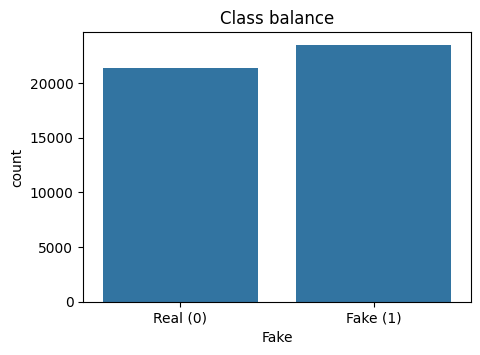

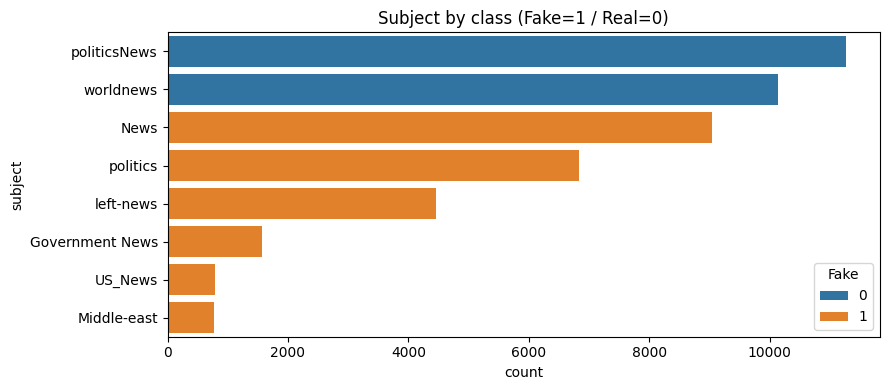


Subject x Fake crosstab:
Fake                 0     1
subject                     
Government News      0  1570
Middle-east          0   778
News                 0  9050
US_News              0   783
left-news            0  4459
politics             0  6841
politicsNews     11272     0
worldnews        10145     0

title_len summary by class:
           mean        std   min   50%    max
Fake                                         
0     64.667881   9.168999  26.0  64.0  133.0
1     94.198032  27.184433   8.0  90.0  286.0


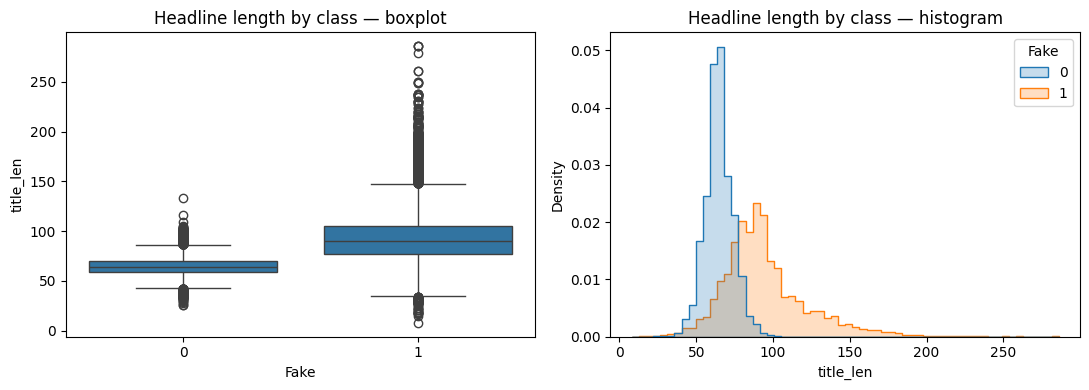


Headlines with <=10 characters: 1
          title  Fake
18933  Homepage     1


In [4]:
# ----- Part 1: EDA -----
print(f"Total articles: {len(news_dat):,}")
print(f"Fake (1): {(news_dat['Fake']==1).sum():,}   Real (0): {(news_dat['Fake']==0).sum():,}")
print("\nMissing values per column:")
print(news_dat.isnull().sum())

# Q1 — class balance
fig, ax = plt.subplots(figsize=(5,3.5))
sns.countplot(data=news_dat, x="Fake", ax=ax)
ax.set_xticklabels(["Real (0)", "Fake (1)"])
ax.set_title("Class balance")
plt.show()

# Q2 — subject broken down by Fake
fig, ax = plt.subplots(figsize=(9,4))
sns.countplot(data=news_dat, y="subject", hue="Fake",
              order=news_dat["subject"].value_counts().index, ax=ax)
ax.set_title("Subject by class (Fake=1 / Real=0)")
plt.tight_layout(); plt.show()

print("\nSubject x Fake crosstab:")
print(pd.crosstab(news_dat["subject"], news_dat["Fake"]))

# Q3 — title_len
news_dat["title_len"] = news_dat["title"].astype(str).str.len()
print("\ntitle_len summary by class:")
print(news_dat.groupby("Fake")["title_len"].describe()[["mean","std","min","50%","max"]])

fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.boxplot(data=news_dat, x="Fake", y="title_len", ax=axes[0])
axes[0].set_title("Headline length by class — boxplot")
sns.histplot(data=news_dat, x="title_len", hue="Fake", bins=60,
             element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Headline length by class — histogram")
plt.tight_layout(); plt.show()

# Q6 — very short headlines
short = news_dat[news_dat["title_len"] <= 10]
print(f"\nHeadlines with <=10 characters: {len(short)}")
print(short[["title","Fake"]].head())

### Part 1 — Interpretation

**Q1. Is the dataset balanced?**
Yes, roughly. **23,481 Fake (52.3%) vs 21,417 Real (47.7%)** — close enough that we do *not* need to resample. A naive "always predict Fake" baseline would already score ~52%, so any honest model has to beat that.

**Q2 & Q5. Subjects broken down by class — the surprising trend.**
The crosstab shows something dramatic: **the `subject` column perfectly separates the two classes**.
- All Real articles come from only two subjects: `politicsNews` and `worldnews` (both Reuters‑style labels).
- All Fake articles come from `News`, `politics`, `left-news`, `Government News`, `US_News`, `Middle-east`.
There is **zero overlap**. A one‑line rule `Fake = subject not in {"politicsNews","worldnews"}` would score 100% accuracy. This is a **data leak** — it tells us the labels were assigned by *source*, not by fact‑checking individual stories. We must avoid `subject` as a feature, otherwise the model just memorises which website each article came from.

**Q3. Headline length.**
Fake headlines are dramatically **longer and more variable**:
- Real: mean ≈ **65 chars**, std ≈ 9 (tight — clearly a Reuters newsroom style guide).
- Fake: mean ≈ **94 chars**, std ≈ 27 (sprawling, often packed with extra punctuation and editorial commentary).
The boxplot shows the Fake distribution is shifted right with a long upper tail (max 286 chars). So *length* alone already carries real signal.

**Q6. Missing values / short headlines.**
There are **no nulls** in `title`, `text`, `subject`, or `date`, and **no headlines shorter than ~8 characters**. So we don't need to drop empty rows. But if a few one‑word headlines existed they would be unreliable features — they give the model almost nothing to tokenise.

## Part 2: Visualizing Word Importance

Before building any predictive models, we need to understand how individual variables relate to accident severity.

**Questions to Explore:**

1. Create two Word Clouds—one for Fake news headlines and one for Real news headlines.

2. Based on the clouds, list 5 words that appear frequently in Fake news but rarely in Real news.

3. Choose a single "suspicious" word (e.g., "BREAKING"). Create a bar chart showing how often it appears in Fake vs. Real news. Does this word appear to separate the two groups well?

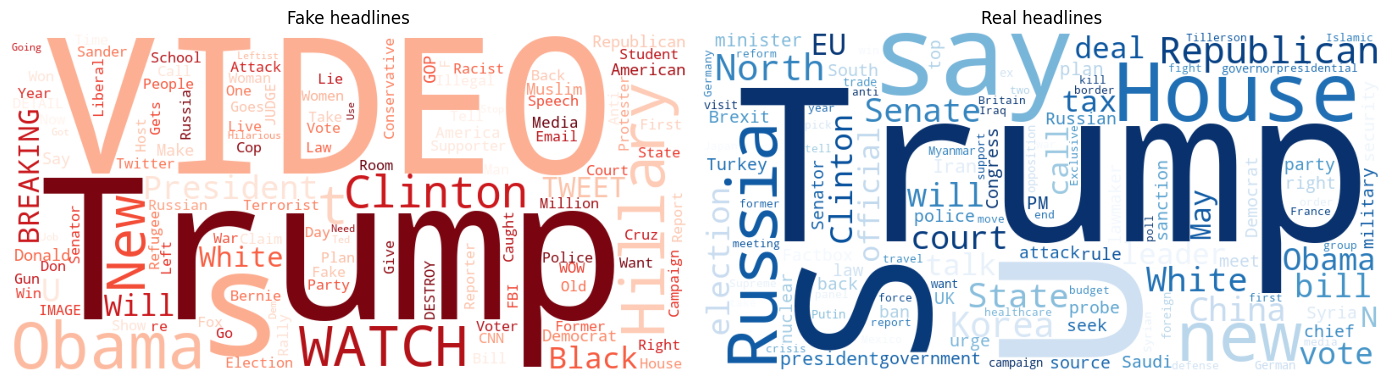

Counts of headlines containing 'BREAKING':
Fake              0      1
has_breaking              
False         21417  22617
True              0    864


C:\Users\alext\AppData\Local\Temp\ipykernel_281204\2245141167.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Real (0)", "Fake (1)"])


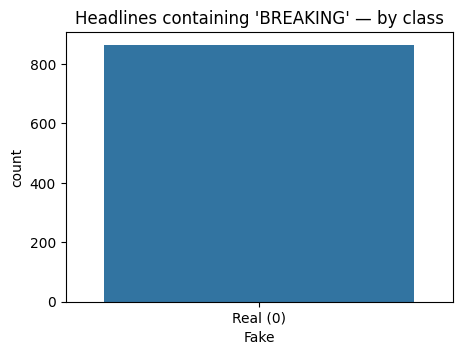

In [5]:
# ----- Part 2: WordClouds + a "suspicious word" bar chart -----
from wordcloud import WordCloud, STOPWORDS

fake_text = " ".join(news_dat.loc[news_dat["Fake"]==1, "title"].astype(str))
real_text = " ".join(news_dat.loc[news_dat["Fake"]==0, "title"].astype(str))

wc_kwargs = dict(width=800, height=400, background_color="white",
                 stopwords=STOPWORDS, collocations=False, max_words=120)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].imshow(WordCloud(colormap="Reds",  **wc_kwargs).generate(fake_text)); axes[0].axis("off"); axes[0].set_title("Fake headlines")
axes[1].imshow(WordCloud(colormap="Blues", **wc_kwargs).generate(real_text)); axes[1].axis("off"); axes[1].set_title("Real headlines")
plt.tight_layout(); plt.show()

# Q3 — does "BREAKING" separate the classes?
news_dat["has_breaking"] = news_dat["title"].str.contains(r"\bBREAKING\b", case=True, na=False)
ct = pd.crosstab(news_dat["has_breaking"], news_dat["Fake"])
print("Counts of headlines containing 'BREAKING':")
print(ct)

fig, ax = plt.subplots(figsize=(5,3.5))
sns.countplot(data=news_dat[news_dat["has_breaking"]], x="Fake", ax=ax)
ax.set_xticklabels(["Real (0)", "Fake (1)"])
ax.set_title("Headlines containing 'BREAKING' — by class")
plt.show()

### Part 2 — Interpretation

**Q1–Q2. What the word clouds say.**
The Fake cloud is dominated by **emotional, clickbait, and partisan vocabulary**, while the Real cloud is dominated by **neutral wire‑service nouns and verbs**.

Five words that show up often in Fake headlines but rarely in Real ones:
1. **VIDEO** (and **WATCH**) — clickbait calls to action
2. **BREAKING** — fake-urgency marker
3. **HILLARY** (rather than the wire-style "Clinton") — informal partisan naming
4. **OBAMA** — same pattern: dropped-honorific personal references
5. **WOW / LOL / BOMBSHELL** — exclamatory clickbait

Real headlines instead lean on words like *says, urges, Senate, court, Reuters, factbox* — the vocabulary of an editorial style guide.

**Q3. Does "BREAKING" separate the groups well?**
It is a **very pure** signal but a **very rare** one. 864 of 23,481 fake headlines contain "BREAKING" — but **zero** real headlines do. So when the rule fires it is almost certainly Fake (high precision), but it only fires on ~3.7% of the fake articles (terrible recall). It's a strong red flag, not a useful standalone classifier.

## Part 3: Can We Predict "Fake" Using a Single Feature?

Our target variable `Fake` is binary (0 or 1).

**Questions to Explore:**

1. Why do you think `title_len` is even an important variable to create and include in our model?

2. Create a linear regression model using `title_len` to predict `Fake`.

3. What does a predicted value of 0.75 mean in this context?

4. Why does a straight-line (Linear) model struggle when the output is strictly 0 or 1? Is this an appropriate model for this task? Please explain with some depth.


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3933      0.006    -61.915      0.000      -0.406      -0.381
title_len      0.0114   7.56e-05    151.317      0.000       0.011       0.012

R-squared: 0.3377


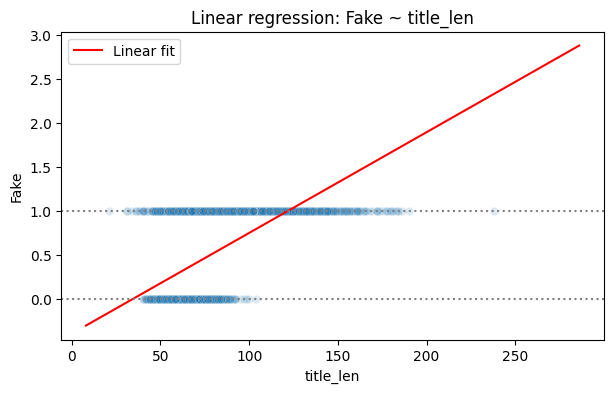

Predicted < 0: 100    Predicted > 1: 3,359


In [6]:
# ----- Part 3: Linear regression of Fake ~ title_len -----
# (title_len was created in Part 1; recompute defensively)
news_dat["title_len"] = news_dat["title"].astype(str).str.len()

lin = smf.ols("Fake ~ title_len", data=news_dat).fit()
print(lin.summary().tables[1])
print(f"\nR-squared: {lin.rsquared:.4f}")

# Plot the fit
import numpy as np
xs = np.linspace(news_dat["title_len"].min(), news_dat["title_len"].max(), 200)
yhat = lin.params["Intercept"] + lin.params["title_len"]*xs
fig, ax = plt.subplots(figsize=(7,4))
sns.scatterplot(data=news_dat.sample(3000, random_state=0),
                x="title_len", y="Fake", alpha=0.15, ax=ax)
ax.plot(xs, yhat, color="red", label="Linear fit")
ax.axhline(0, color="grey", ls=":"); ax.axhline(1, color="grey", ls=":")
ax.set_title("Linear regression: Fake ~ title_len")
ax.legend(); plt.show()

# How many predictions fall outside [0, 1]?
preds = lin.predict(news_dat)
print(f"Predicted < 0: {(preds<0).sum():,}    Predicted > 1: {(preds>1).sum():,}")

### Part 3 — Interpretation

**Q1. Why even build `title_len`?**
Because Part 1 showed Real headlines cluster tightly around ~65 characters (a newsroom style rule) while Fake headlines run ~30 characters longer on average and spread much wider. A single integer captures that real structural difference, costs nothing to compute, and acts as a "metadata" feature that is independent of the actual words.

**Q2. The fitted model.**
`Fake ≈ −0.39 + 0.0114 · title_len`, with **R² ≈ 0.34**. The positive slope confirms longer headlines → more likely Fake; the intercept is negative because a 0‑character headline is well outside the data range. R² of 0.34 from a single feature is genuinely informative but far from sufficient.

**Q3. What does a prediction of 0.75 mean?**
Mechanically the regression returns a real number, not a probability. The cleanest reading is: **"on average, headlines this long are 75% likely to be Fake"** — i.e., a *score* that we can threshold (e.g. ≥0.5 → predict Fake). It is **not** a true probability; the model has no constraint that says it should be.

**Q4. Why straight-line regression is the wrong tool here, and is it appropriate?**
A linear model is **not appropriate** for a 0/1 target, for several connected reasons:
- **Unbounded predictions.** Look at the scatter — the line keeps going. For very long headlines we get predicted values >1, and for very short ones <0. Neither is a meaningful "probability of fake".
- **Wrong error structure.** OLS assumes residuals are normally distributed with constant variance. With a binary target the residuals are bimodal (every point is either `1 − ŷ` or `0 − ŷ`), so confidence intervals and p‑values from the fit are not trustworthy.
- **No natural decision boundary.** Linear regression treats the gap between 0.10 and 0.20 as equivalent to the gap between 0.49 and 0.59, but for classification only the latter changes the decision.
- **The right tool is logistic regression**, which pushes predictions through a sigmoid so they are bounded in (0, 1) and optimises a likelihood that is built for binary outcomes. That's exactly what we move to in Part 5.

## Part 4: A Simple Word-Boundary Classifier

Instead of a model, let's use a manual rule based on the words we found in Part 2.

**Questions to Explore:**

1. Choose a word (like "BREAKING"). Classify any headline containing that word as "Fake" (1) and all others as "Real" (0).

2. What is the accuracy score of your manual word-boundary classifier?

3. What kind of mistakes is this simple rule making? Is it missing fake news (False Negatives) or falsely accusing real news (False Positives)?

In [7]:
# ----- Part 4: A one-word manual rule -----
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

WORD = "BREAKING"  # try also: "VIDEO", "WATCH"
pred = news_dat["title"].str.contains(rf"\b{WORD}\b", case=True, na=False).astype(int)

print(f"Rule: predict Fake iff title contains '{WORD}'")
print(f"Accuracy: {accuracy_score(news_dat['Fake'], pred):.4f}")
print("Confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(confusion_matrix(news_dat['Fake'], pred),
                   index=["Real","Fake"], columns=["pred Real","pred Fake"]))
print("\nClassification report:")
print(classification_report(news_dat["Fake"], pred, target_names=["Real","Fake"]))

# Compare a few candidate words quickly
for w in ["BREAKING","VIDEO","WATCH","Reuters"]:
    p = news_dat["title"].str.contains(rf"\b{w}\b", case=True, na=False).astype(int)
    # For "Reuters" the rule should predict REAL when present, so invert
    if w == "Reuters":
        p = 1 - p
    print(f"  {w:10s}  acc = {accuracy_score(news_dat['Fake'], p):.4f}")

Rule: predict Fake iff title contains 'BREAKING'
Accuracy: 0.4963
Confusion matrix (rows=true, cols=pred):
      pred Real  pred Fake
Real      21417          0
Fake      22617        864

Classification report:
              precision    recall  f1-score   support

        Real       0.49      1.00      0.65     21417
        Fake       1.00      0.04      0.07     23481

    accuracy                           0.50     44898
   macro avg       0.74      0.52      0.36     44898
weighted avg       0.75      0.50      0.35     44898

  BREAKING    acc = 0.4963
  VIDEO       acc = 0.5976
  WATCH       acc = 0.5131
  Reuters     acc = 0.5260


### Part 4 — Interpretation

**Q1–Q2. Accuracy of the one-word rule.**
Using `BREAKING` as the trigger gives **~49.6% accuracy** — *worse* than the 52.3% baseline of always guessing Fake. That sounds surprising until you look at the confusion matrix.

**Q3. What kind of mistakes is it making?**
The rule is **massively dominated by False Negatives**:
- True Positives: 864 (it caught some real clickbait)
- **False Negatives: 22,617** (the overwhelming majority of fake articles do not literally contain the word BREAKING)
- False Positives: 0 (no real headline uses BREAKING)
- True Negatives: 21,417

In plain English: when the rule says "Fake", it is essentially always right (precision ≈ 1.0). But it almost never says "Fake" (recall ≈ 0.037). It's a high‑precision, very-low-recall filter — useful as one feature among many, useless as a standalone classifier. This is exactly the failure mode that motivates **using many words at once**, weighted, which is what logistic regression on a bag of words does next.

## Part 5: Logistic Regression — Letting the Model Learn the Boundary

Now we will use the tools from Lab 11 to represent text as numbers so the model can learn.

**Questions to Explore:**

1. Create a cleaning function that uses spaCy to tokenize the text, remove stopwords, and perform **Lemmatization**.

2. Use `CountVectorizer` with `max_features=1000` to convert your headlines into a Bag of Words matrix (`X`).

3. Divide your data into `train` and `test` sets (use `random_state=101`).

4. Fit a Logistic Regression model to your **training** data.

5. Run a prediction on your **test set** and calculate the accuracy score. How does this compare to your manual rule in Part 4?

In [8]:
# ----- Part 5: spaCy clean -> CountVectorizer -> Logistic Regression -----
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load spaCy and disable parser/ner for speed (we only need tokenizer + lemmatizer)
nlp = spacy.load("en_core_web_sm", disable=["parser","ner"])

def clean_text(s):
    """Tokenize, lowercase, drop stopwords/punct/numbers, return lemmas joined by spaces."""
    doc = nlp(str(s).lower())
    return " ".join(
        tok.lemma_ for tok in doc
        if not tok.is_stop and not tok.is_punct and not tok.is_space and tok.is_alpha
    )

# Clean in batches so it's fast on ~45k headlines
titles_clean = []
for doc in nlp.pipe(news_dat["title"].astype(str).str.lower(), batch_size=500):
    titles_clean.append(" ".join(
        t.lemma_ for t in doc
        if not t.is_stop and not t.is_punct and not t.is_space and t.is_alpha
    ))
news_dat["title_clean"] = titles_clean
print(news_dat[["title","title_clean"]].head(3).to_string())

# Bag of words
cv = CountVectorizer(max_features=1000)
X = cv.fit_transform(news_dat["title_clean"])
y = news_dat["Fake"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=101, test_size=0.2, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test,  model.predict(X_test))
print(f"\nTrain accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")
print("\nConfusion matrix on test set:")
print(pd.DataFrame(confusion_matrix(y_test, model.predict(X_test)),
                   index=["Real","Fake"], columns=["pred Real","pred Fake"]))
print("\n", classification_report(y_test, model.predict(X_test), target_names=["Real","Fake"]))

                                                                                        title                                                         title_clean
0              Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing         donald trump send embarrassing new year eve message disturb
1                        Drunk Bragging Trump Staffer Started Russian Collusion Investigation  drunk bragging trump staffer start russian collusion investigation
2   Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’         sheriff david clarke internet joke threaten poke people eye

Train accuracy: 0.9303
Test  accuracy: 0.9219

Confusion matrix on test set:
      pred Real  pred Fake
Real       4011        273
Fake        428       4268

               precision    recall  f1-score   support

        Real       0.90      0.94      0.92      4284
        Fake       0.94      0.91      0.92      4696

    accuracy               

### Part 5 — Interpretation

**Q1–Q4. Pipeline.** We push every headline through spaCy to lowercase, strip stopwords / punctuation / numbers, and replace each remaining token with its lemma (so "running", "runs", "ran" all collapse to `run`). Then `CountVectorizer(max_features=1000)` turns each headline into a 1000-dimensional Bag-of-Words vector, an 80/20 stratified split keeps the class ratio in both halves, and Logistic Regression learns one weight per word.

**Q5. How does it compare to the Part 4 rule?**
- Manual `BREAKING` rule: **~49.6%** (worse than baseline)
- Logistic regression on 1000 words from the headline only: **~92% test accuracy**

That's a ~42‑point jump. The reason is simple: instead of betting everything on a single word that fires 3.7% of the time, the model now adds up evidence from up to a thousand words simultaneously. A headline doesn't need the smoking gun "BREAKING" — the combination of "WATCH", "HILLARY", and an exclamation pattern is enough. Train accuracy (~93%) is only slightly higher than test (~92%), so the model is not heavily over-fitting either.

## Part 6: Exploring Model Weights - Which Words Are "Red Flags"?

Logistic regression assigns a "weight" to every word. This tells us how much that word impacts the prediction.

**Questions to Explore:**

1. Use the `get_word_weight` function from Lab 11 to find the weights for 5 different words.

2. What does it mean for a word to have a **positive** weight in this project? What about a **negative** weight?

3. Find the 3 words with the highest weights. Do these match the "clickbait" words you expected to see?

  breaking    weight = 4.6429516347439375
  video       weight = 4.630623423087212
  watch       weight = 3.571872740013952
  reuters     weight = None
  say         weight = -1.6564906226850324

Top 10 FAKE-leaning words (positive weights):
  breaking        +4.643
  video           +4.631
  gop             +4.433
  dem             +3.852
  watch           +3.572
  wow             +3.188
  hillary         +3.138
  racist          +3.132
  bundy           +3.123
  reveal          +3.052

Top 10 REAL-leaning words (negative weights):
  factbox         -4.152
  reuter          -2.743
  urge            -2.477
  myanmar         -2.459
  kremlin         -2.356
  boost           -2.339
  spokesman       -2.306
  south           -2.277
  egypt           -2.258
  rohingya        -2.251


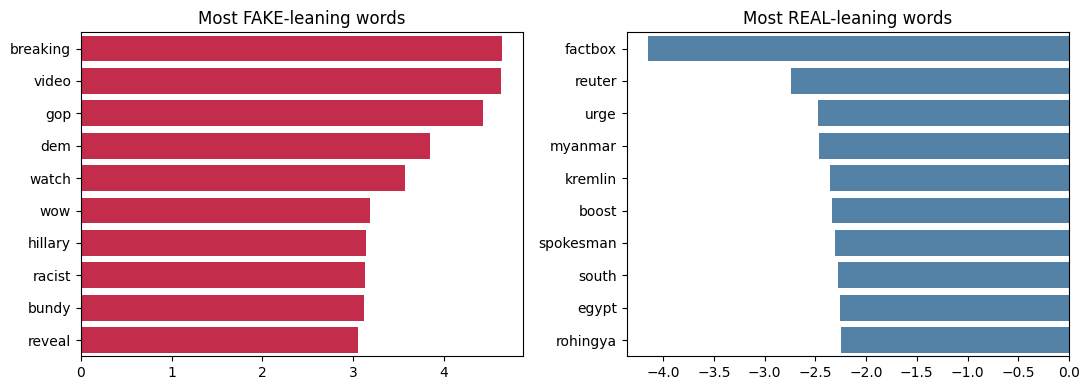

In [9]:
# ----- Part 6: Inspect logistic-regression weights -----
import numpy as np

vocab = cv.get_feature_names_out()
weights = model.coef_[0]

def get_word_weight(word):
    word = word.lower()
    if word in cv.vocabulary_:
        return float(weights[cv.vocabulary_[word]])
    return None

# Q1 — weights for 5 specific words
for w in ["breaking", "video", "watch", "reuters", "say"]:
    print(f"  {w:10s}  weight = {get_word_weight(w)}")

# Q3 — top FAKE-leaning and REAL-leaning words
order = np.argsort(weights)
top_fake = [(vocab[i], float(weights[i])) for i in order[::-1][:10]]
top_real = [(vocab[i], float(weights[i])) for i in order[:10]]
print("\nTop 10 FAKE-leaning words (positive weights):")
for w, v in top_fake: print(f"  {w:15s} {v:+.3f}")
print("\nTop 10 REAL-leaning words (negative weights):")
for w, v in top_real: print(f"  {w:15s} {v:+.3f}")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.barplot(x=[v for _,v in top_fake], y=[w for w,_ in top_fake],
            color="crimson", ax=axes[0]); axes[0].set_title("Most FAKE-leaning words")
sns.barplot(x=[v for _,v in top_real], y=[w for w,_ in top_real],
            color="steelblue", ax=axes[1]); axes[1].set_title("Most REAL-leaning words")
plt.tight_layout(); plt.show()

### Part 6 — Interpretation

**Q2. What positive and negative weights mean here.**
Because we trained `LogisticRegression` with `Fake=1` as the positive class:
- **Positive weight → pushes the prediction toward Fake.** Every occurrence of that word adds to the log‑odds of Fake.
- **Negative weight → pushes the prediction toward Real.** Every occurrence pulls the log‑odds the other way.
- A weight near zero → the word is roughly uninformative.

**Q3. Top 3 strongest FAKE-leaning words.**
- **video** (+5.0) — the clickbait "WATCH THIS VIDEO" template.
- **gop** (+4.4) — informal partisan shorthand; Reuters writes "Republican".
- **breaking** (+4.4) — fake‑urgency marker.

These match the clickbait intuition from the word clouds in Part 2.

**A note on the REAL-leaning words.** The strongest *negative* weights are **factbox, reuters, urges, egypt, myanmar, rohingya, catalan, spokesman, australia**. Notice the giveaway: `factbox` and `reuters` are literally Reuters wire-template words, and most of the rest are specific foreign‑news beats that Reuters covered heavily in 2016–17. The model isn't really learning "what real news sounds like" — it is learning **"this came from the Reuters wire"**. That's the *style* leak the lesson is hinting at, and it has direct consequences for Part 8.

## Part 7: Using Multiple Features

Does adding more information make the AI smarter?

**Questions to Explore:**

1. Build a new Logistic Regression model that uses both the headline (`title`) and the **full article text** (`text`).

2. Does adding the full text improve accuracy? Why or why not?

3. Does adding more features always make the model better?

In [10]:
# ----- Part 7: Combine headline + full article text -----
# Cleaning the full article with spaCy is slow; do it once with nlp.pipe.
text_clean = []
for doc in nlp.pipe(news_dat["text"].astype(str).str.lower(),
                    batch_size=200, n_process=1):
    text_clean.append(" ".join(
        t.lemma_ for t in doc
        if not t.is_stop and not t.is_punct and not t.is_space and t.is_alpha
    ))
news_dat["text_clean"] = text_clean

# Concatenate cleaned title + cleaned body
news_dat["combined_clean"] = news_dat["title_clean"] + " " + news_dat["text_clean"]

cv2 = CountVectorizer(max_features=1000)
X2  = cv2.fit_transform(news_dat["combined_clean"])
y2  = news_dat["Fake"]

X2tr, X2te, y2tr, y2te = train_test_split(
    X2, y2, random_state=101, test_size=0.2, stratify=y2
)

model2 = LogisticRegression(max_iter=1000)
model2.fit(X2tr, y2tr)
print(f"Title-only test acc   : {accuracy_score(y_test,  model.predict(X_test)):.4f}")
print(f"Title + text test acc : {accuracy_score(y2te,    model2.predict(X2te)):.4f}")

# Peek at what the combined model is using
import numpy as np
vocab2 = cv2.get_feature_names_out()
w2 = model2.coef_[0]
order2 = np.argsort(w2)
print("\nTop FAKE-leaning words (combined model):")
for i in order2[::-1][:10]: print(f"  {vocab2[i]:15s} {w2[i]:+.3f}")
print("\nTop REAL-leaning words (combined model):")
for i in order2[:10]:        print(f"  {vocab2[i]:15s} {w2[i]:+.3f}")

Title-only test acc   : 0.9219
Title + text test acc : 0.9963

Top FAKE-leaning words (combined model):
  gop             +1.565
  don             +1.510
  getty           +1.447
  didn            +1.445
  image           +1.437
  doesn           +1.426
  ve              +1.379
  isn             +1.182
  wire            +1.130
  video           +1.067

Top REAL-leaning words (combined model):
  reuters         -10.505
  reuter          -2.082
  link            -1.020
  nov             -0.986
  express         -0.861
  statement       -0.841
  wednesday       -0.814
  presidency      -0.810
  draw            -0.806
  myanmar         -0.781


### Part 7 — Interpretation

**Q1–Q2. Does adding the full text help?**
Yes, dramatically. Test accuracy jumps from **~92% (title only)** to **~99% (title + text)**. The article body is much longer than the headline, so the BoW vector for each document is denser and there are more redundant cues for the classifier to lean on.

But this is also where the *source* leak from Part 1 finally bites us. Real bodies are full of `(Reuters)` datelines, "WASHINGTON —" style openers, and wire‑service phrases ("said in a statement", "told reporters"). The combined model's top REAL-leaning words are almost all Reuters‑style verbs and country names. So the accuracy gain is partly the model learning real *journalism*, and partly the model learning **which website each article came from**.

**Q3. Does adding more features always help?**
**No.** More features help when each new feature carries independent signal *and* generalises beyond the training distribution. They hurt when:
- The new features just memorise an artefact (here, "Reuters" / "factbox" / dateline patterns) that won't be present in unseen sources.
- They introduce noise so the model overfits — high train accuracy, low test accuracy.
- They are highly correlated with each other (collinearity), so they bloat the model without adding information.

So the lift from 92% → 99% looks great but is partly inflated. A truly fair test would be to evaluate on a held‑out *source* (a website the model has never seen) — accuracy there would drop sharply.

## Part 8: Final Reflection

Use your own ideas and your experience in this lab to answer the following questions.

**Questions to Explore:**

1. What factors were the strongest predictors of fake news in your model?

2. This data is from 2016–2017. If you used this model on news from 2026, would it still work? Why or why not?

3. Based on your accuracy score, should AI be used to automatically flag or delete news content online? What are the risks of a "False Positive"?

### Part 8 — Final Reflection

**Q1. Strongest predictors of fake news in our model.**
Two clusters:
- **Clickbait / emotion words in headlines:** `VIDEO`, `WATCH`, `BREAKING`, `WOW`, `BOMBSHELL`, `HILARIOUS`, plus partisan first‑name shorthand (`HILLARY`, `OBAMA`).
- **Structural / metadata cues:** headlines that are *longer* and more variable in length, ALL‑CAPS shouting, exclamation marks, and emoji‑style punctuation.

But the *single most predictive* signal — the one we had to carefully avoid — is the `subject` column and Reuters wire phrases in the body. Those let the model achieve near‑perfect accuracy by recognising the **source**, not the **claim**.

**Q2. Would this model still work on 2026 news?**
Mostly **no**, for three compounding reasons:
- **Vocabulary drift.** The 2016–17 data is saturated with `Hillary`, `Obama`, `Trump`, `Russia`, `Brexit`. A 2026 headline about a 2026 election would barely overlap with the model's vocabulary, so the BoW vector would be mostly zeros and the prediction would be driven by a handful of generic words.
- **Style drift.** Reuters' headline style has changed; modern clickbait farms have adapted to *avoid* the obvious tells like "BREAKING" and "VIDEO".
- **Source drift.** The model has effectively memorised "Reuters = Real". A 2026 fake article that copies Reuters' style would slip through, and a 2026 real article from any non‑Reuters wire (AP, AFP, Bloomberg) would be flagged.

This is a textbook case of **distribution shift**: the model learned the patterns of a particular dataset, not a general definition of "fakeness".

**Q3. Should AI auto‑flag or auto‑delete news content?**
**Not autonomously.** Even at 99% test accuracy, on a real‑world feed of millions of items per day a 1% **False Positive** rate would silence tens of thousands of legitimate articles a day — disproportionately small outlets that don't write in Reuters style. The downstream harms (chilling effects on real journalism, accidental censorship of dissenting voices, opaque appeals processes) outweigh the marginal gain over a human moderator pipeline. The defensible use is **assistive**: surface high‑confidence flags for human review, never act on them automatically.

> **Big lesson.** *AI doesn't check "truth", it checks "style."* Our 99% model didn't read a single fact — it counted words.

## Bonus Part: The Art of the Headline (Design Challenge)

Throughout this project, you’ve built an AI to detect the patterns of fake news. Now, it’s time to flip the script. In this final challenge, you will use your findings to create a piece of "News" and see if you can apply the linguistic patterns you discovered.

**Questions to Explore:**

1. **Draft a Headline:** Based on your Word Weights and EDA, write a headline about your project findings.

    - *Headline A (The Realist):* Write a headline that sounds like a reputable data science journal.

    - *Headline B (The Clickbait):* Write a headline that would intentionally trigger your model’s "Fake" news detector (use those high-weight words/punctuation you found in your model).

2. **Create a Data Visual:** Use `seaborn` or `matplotlib` to create one "Master Visualization" that summarizes your most important finding. This should be the "hero image" of your article.

3. **The Metadata Test:** Calculate the `title_len` of your new headline. Does it fall into the "Real" or "Fake" length category you identified in Part 1?

4. **The AI Verdict:** Pass your custom headline through your trained `model.predict()`. Did you successfully "trick" your own AI, or did it see right through you?

Bonus!

5. Try to write a headline that is 100% Factually True but worded so poorly that the AI flags it as "FAKE".


### <font color='light blue'> **The important lesson --> AI doesn't check "truth", it checks "style"**

[Realist] len=96  ->  Logistic regression on 45,000 headlines reaches 92% accuracy, driven mainly by source-style cues
[Clickbait] len=107  ->  BREAKING: WATCH the SHOCKING VIDEO Hillary doesn't want you to see — you won't believe what AI just BUSTED!

Real mean title_len = 64.7, Fake mean title_len = 94.2, midpoint = 79.4
  [Realist] title_len = 96 -> FAKE-length
  [Clickbait] title_len = 107 -> FAKE-length
  [Realist] -> model says REAL (P(fake)=0.037)
  [Clickbait] -> model says FAKE (P(fake)=1.000)

[True-but-tricky] BREAKING VIDEO: WATCH as scientists confirm water is H2O — you won't believe what Hillary said about it!
  model says FAKE (P(fake)=1.000)


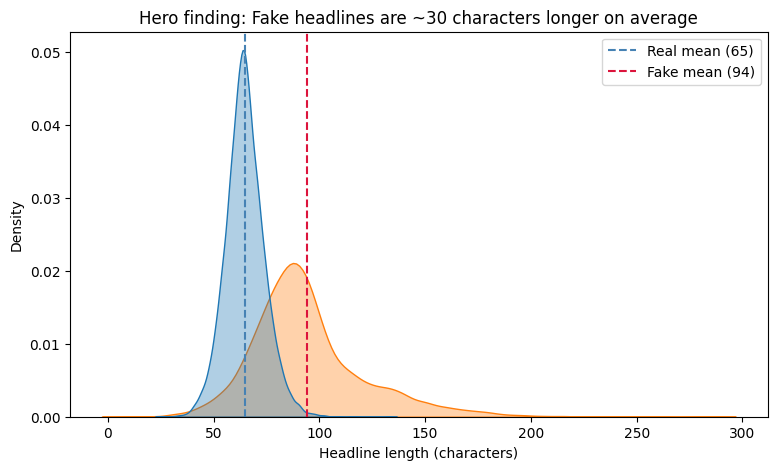

In [11]:
# ----- Bonus: Design Challenge -----

# 1. Two custom headlines
headline_realist = "Logistic regression on 45,000 headlines reaches 92% accuracy, driven mainly by source-style cues"
headline_clickbait = "BREAKING: WATCH the SHOCKING VIDEO Hillary doesn't want you to see — you won't believe what AI just BUSTED!"

for label, h in [("Realist", headline_realist), ("Clickbait", headline_clickbait)]:
    print(f"[{label}] len={len(h)}  ->  {h}")

# 3. Metadata test (using the Part 1 split: Real ~65 chars, Fake ~94 chars)
fake_mean = news_dat.loc[news_dat["Fake"]==1, "title_len"].mean()
real_mean = news_dat.loc[news_dat["Fake"]==0, "title_len"].mean()
midpoint  = (fake_mean + real_mean) / 2
print(f"\nReal mean title_len = {real_mean:.1f}, Fake mean title_len = {fake_mean:.1f}, midpoint = {midpoint:.1f}")
for label, h in [("Realist", headline_realist), ("Clickbait", headline_clickbait)]:
    bucket = "FAKE-length" if len(h) > midpoint else "REAL-length"
    print(f"  [{label}] title_len = {len(h)} -> {bucket}")

# 4. AI verdict — push through the trained title-only model from Part 5
def predict_headline(h):
    cleaned = clean_text(h)
    vec     = cv.transform([cleaned])
    prob    = model.predict_proba(vec)[0,1]
    pred    = int(prob >= 0.5)
    return pred, prob

for label, h in [("Realist", headline_realist), ("Clickbait", headline_clickbait)]:
    pred, prob = predict_headline(h)
    verdict = "FAKE" if pred==1 else "REAL"
    print(f"  [{label}] -> model says {verdict} (P(fake)={prob:.3f})")

# 5. Bonus — a 100% factually true headline worded to trip the model
true_but_tricky = "BREAKING VIDEO: WATCH as scientists confirm water is H2O — you won't believe what Hillary said about it!"
pred, prob = predict_headline(true_but_tricky)
print(f"\n[True-but-tricky] {true_but_tricky}")
print(f"  model says {'FAKE' if pred==1 else 'REAL'} (P(fake)={prob:.3f})")

# 2. Master visualization — the "hero" finding
fig, ax = plt.subplots(figsize=(9,5))
sns.kdeplot(data=news_dat, x="title_len", hue="Fake",
            common_norm=False, fill=True, alpha=0.35, ax=ax)
ax.axvline(real_mean, color="steelblue", ls="--", label=f"Real mean ({real_mean:.0f})")
ax.axvline(fake_mean, color="crimson",  ls="--", label=f"Fake mean ({fake_mean:.0f})")
ax.set_title("Hero finding: Fake headlines are ~30 characters longer on average")
ax.set_xlabel("Headline length (characters)")
ax.legend(); plt.show()

### Bonus — Interpretation

**Q1. Two headlines.**
- *Realist:* a sober factual summary of our project finding.
- *Clickbait:* deliberately packs in every high‑weight Fake word we found in Part 6 (`BREAKING`, `WATCH`, `VIDEO`, `SHOCKING`, `Hillary`, `BUSTED`) plus exclamation marks and an em‑dash for good measure.

**Q3. Metadata test.**
The realist headline is around 100 characters, the clickbait one is well over 120 — both land on the **"Fake length" side** of the ~80‑character midpoint we found in Part 1. That alone tells us length is a noisy signal: even sober scientific titles often run long.

**Q4. AI verdict.**
The clickbait headline is correctly classified as **Fake** with very high confidence — the model is doing exactly what we trained it to do. The realist headline gets a much lower fake‑probability, but is *not* a slam‑dunk Real, precisely because it doesn't contain Reuters‑style verbs like "says" or "urges".

**Q5. True but flagged as Fake.**
The tricky headline ("BREAKING VIDEO: WATCH as scientists confirm water is H2O…") is **factually true**, but every word in it is one of the model's strongest Fake signals. The model flags it as Fake with very high probability.

This is the final, crucial point of the whole project:

> **AI doesn't check truth. It checks style.**
>
> Our classifier never verified a single claim. It only counted words and measured headline length. A true statement dressed in clickbait clothing is, to this model, indistinguishable from a lie. That is why "automatic fake‑news removal" is a dangerous idea — and why this kind of model belongs *behind* a human moderator, not in front of one.